## Cálculo do índice de vulnerabilidade

O primeiro desafio é associar cada um dos bairros do Rio com uma estação meteorológica mais próxima

In [1]:
# ── Célula 1: imports e carregamento ──
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("../figuras", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

# ── Célula 1 revisada: carregar com recorte 2017-2024 ──
df_eventos = pd.read_parquet(
    "../data/processed/chamados_alagamento.parquet",
    columns=["id_chamado", "data_inicio", "data", "ano", "mes",
             "categoria_chamado", "id_bairro", "bairro", "latitude", "longitude"]
)

df_chuva = pd.read_parquet(
    "../data/processed/chuva_alertario.parquet",
    columns=["id_estacao", "data", "acumulado_chuva_24_h", "nome", "ano", "mes"]
)

# Filtrar apenas eventos reais 2017-2024
df_eventos = df_eventos[
    (df_eventos["categoria_chamado"] == "evento_alagamento") &
    (df_eventos["bairro"].notna()) &
    (df_eventos["ano"] >= 2017) &
    (df_eventos["ano"] <= 2024)
].copy()

df_eventos["data"] = pd.to_datetime(df_eventos["data"])
df_chuva["data"]   = pd.to_datetime(df_chuva["data"])

print(f"Eventos carregados:        {len(df_eventos):,}")
print(f"Registros de chuva:        {len(df_chuva):,}")
print(f"Período eventos:           {df_eventos['ano'].min()} a {df_eventos['ano'].max()}")
print(f"Bairros únicos:            {df_eventos['bairro'].nunique()}")
print(f"\nEventos por ano:")
print(df_eventos.groupby("ano").size())

Eventos carregados:        335
Registros de chuva:        16,876,021
Período eventos:           2017 a 2024
Bairros únicos:            87

Eventos por ano:
ano
2017     41
2018    106
2019     27
2020     18
2021     10
2022     19
2023     33
2024     81
dtype: int64


In [3]:
# ── Célula 2: associar bairros às estações mais próximas ──
from google.cloud import bigquery
import geopandas as gpd
from shapely.wkt import loads as wkt_loads

PROJECT_ID = "ps-analytica-495522"
client = bigquery.Client(project=PROJECT_ID)

# Carregar centroides dos bairros
query_bairros_geo = """
SELECT id_bairro, nome,
    ST_CENTROID(geometry) as centroide
FROM `datario.dados_mestres.bairro`
"""
df_bairros_geo = client.query(query_bairros_geo).to_dataframe()
df_bairros_geo["geometry"] = df_bairros_geo["centroide"].apply(wkt_loads)

gdf_bairros = gpd.GeoDataFrame(
    df_bairros_geo[["id_bairro", "nome", "geometry"]],
    geometry="geometry", crs="EPSG:4326"
).to_crs("EPSG:31983")

gdf_bairros["bairro"] = (
    gdf_bairros["nome"].str.strip().str.upper().str.normalize("NFC")
)

# Carregar estações com coordenadas
query_estacoes = """
SELECT id_estacao, estacao, latitude, longitude
FROM `datario.clima_pluviometro.estacoes_alertario`
"""
df_estacoes = client.query(query_estacoes).to_dataframe()

gdf_estacoes = gpd.GeoDataFrame(
    df_estacoes,
    geometry=gpd.points_from_xy(df_estacoes["longitude"], df_estacoes["latitude"]),
    crs="EPSG:4326"
).to_crs("EPSG:31983")

# Associar cada bairro à estação mais próxima
gdf_bairros = gpd.sjoin_nearest(
    gdf_bairros,
    gdf_estacoes[["id_estacao", "estacao", "geometry"]],
    how="left"
)

bairro_estacao = gdf_bairros[["bairro", "id_estacao", "estacao"]].copy()
bairro_estacao["id_estacao"] = bairro_estacao["id_estacao"].astype(str)

print(f"Bairros associados a estações: {len(bairro_estacao)}")
print(bairro_estacao.head(10).to_string(index=False))

Bairros associados a estações: 166
      bairro id_estacao            estacao
        CAJU         32      Sao cristovao
SANTO CRISTO         15              Saude
      GAMBOA         15              Saude
       SAÚDE         15              Saude
      CENTRO         15              Saude
        LAPA         15              Saude
     PAQUETÁ          8 Ilha do governador
SANTA TERESA          5       Santa teresa
RIO COMPRIDO          5       Santa teresa
     ESTÁCIO          5       Santa teresa


In [4]:
# ── Célula 3: agregar chuva diária por estação ──

# Usar acumulado_chuva_24h máximo do dia
# máximo captura melhor eventos extremos que a média
chuva_diaria = (
    df_chuva
    .groupby(["id_estacao", "data"])["acumulado_chuva_24_h"]
    .max()
    .reset_index()
    .rename(columns={"acumulado_chuva_24_h": "chuva_max_24h"})
)

chuva_diaria["id_estacao"] = chuva_diaria["id_estacao"].astype(str)

print(f"Registros de chuva diária: {len(chuva_diaria):,}")
print(f"\nEstatísticas gerais:")
print(chuva_diaria["chuva_max_24h"].describe().round(1))

Registros de chuva diária: 170,090

Estatísticas gerais:
count    169953.0
mean          6.3
std          16.6
min           0.0
25%           0.0
50%           0.0
75%           5.2
max        2023.2
Name: chuva_max_24h, dtype: float64


In [5]:
# ── Célula 4: cruzar eventos com precipitação ──

# Adicionar estação a cada evento via bairro
df_eventos_est = df_eventos.merge(
    bairro_estacao[["bairro", "id_estacao", "estacao"]],
    on="bairro",
    how="left"
)

# Cruzar com chuva do mesmo dia na estação mais próxima
df_cruzado = df_eventos_est.merge(
    chuva_diaria,
    on=["id_estacao", "data"],
    how="left"
)

print(f"Total de eventos:            {len(df_cruzado):,}")
print(f"Com chuva associada:         {df_cruzado['chuva_max_24h'].notna().sum():,}")
print(f"Sem chuva associada:         {df_cruzado['chuva_max_24h'].isna().sum():,}")
print(f"\nEstatísticas de chuva nos dias de evento:")
print(df_cruzado["chuva_max_24h"].describe().round(1))

# Verificar eventos com chuva zero ou muito baixa
print(f"\nEventos com chuva = 0mm:     {(df_cruzado['chuva_max_24h'] == 0).sum():,}")
print(f"Eventos com chuva < 5mm:     {(df_cruzado['chuva_max_24h'] < 5).sum():,}")
print(f"Eventos com chuva >= 5mm:    {(df_cruzado['chuva_max_24h'] >= 5).sum():,}")

Total de eventos:            335
Com chuva associada:         277
Sem chuva associada:         58

Estatísticas de chuva nos dias de evento:
count    277.0
mean       7.4
std       21.4
min        0.0
25%        0.0
50%        0.0
75%        4.0
max      199.6
Name: chuva_max_24h, dtype: float64

Eventos com chuva = 0mm:     140
Eventos com chuva < 5mm:     212
Eventos com chuva >= 5mm:    65


In [6]:
# ── Célula 5: construção do índice de vulnerabilidade hídrica ──

LIMIAR_CHUVA_MM = 5  # ignorar dias com chuva insignificante

# Filtrar apenas dias com chuva acima do limiar
df_indice = df_cruzado[
    df_cruzado["chuva_max_24h"] >= LIMIAR_CHUVA_MM
].copy()

print(f"Eventos com chuva >= {LIMIAR_CHUVA_MM}mm: {len(df_indice):,}")

# Calcular índice diário: eventos por mm de chuva
df_indice["indice_diario"] = df_indice["chuva_max_24h"] / df_indice["chuva_max_24h"]

# Agregar por bairro
vulnerabilidade = (
    df_indice.groupby("bairro")
    .agg(
        total_eventos      = ("id_chamado", "count"),
        total_chuva_mm     = ("chuva_max_24h", "sum"),
        media_chuva_mm     = ("chuva_max_24h", "mean"),
        mediana_indice     = ("indice_diario", "median"),
        dias_com_evento    = ("data", "nunique"),
        anos_cobertos      = ("ano", "nunique")
    )
    .reset_index()
)

# Índice principal: eventos por mm de chuva acumulada
vulnerabilidade["ivh"] = (
    vulnerabilidade["total_eventos"] / vulnerabilidade["total_chuva_mm"]
).round(6)

# Normalizar IVH para escala 0-100
ivh_min = vulnerabilidade["ivh"].min()
ivh_max = vulnerabilidade["ivh"].max()
vulnerabilidade["ivh_normalizado"] = (
    (vulnerabilidade["ivh"] - ivh_min) / (ivh_max - ivh_min) * 100
).round(1)

vulnerabilidade = vulnerabilidade.sort_values("ivh_normalizado", ascending=False)

print(f"\nTop 20 bairros mais vulneráveis:")
print(
    vulnerabilidade.head(20)
    [["bairro", "total_eventos", "total_chuva_mm", "dias_com_evento", "ivh", "ivh_normalizado"]]
    .to_string(index=False)
)

Eventos com chuva >= 5mm: 65

Top 20 bairros mais vulneráveis:
                   bairro  total_eventos  total_chuva_mm  dias_com_evento      ivh  ivh_normalizado
      SENADOR VASCONCELOS              1             7.0                1 0.142857            100.0
            BENTO RIBEIRO              1             7.6                1 0.131579             91.8
        ILHA DE GUARATIBA              1             8.4                1 0.119048             82.7
IMPERIAL DE SÃO CRISTÓVÃO              1             8.8                1 0.113636             78.8
           JARDIM SULACAP              1             9.4                1 0.106383             73.5
           JARDIM AMÉRICA              1            10.0                1 0.100000             68.9
  FREGUESIA (JACAREPAGUÁ)              1            10.0                1 0.100000             68.9
             PADRE MIGUEL              2            21.8                2 0.091743             62.9
                    ROCHA            

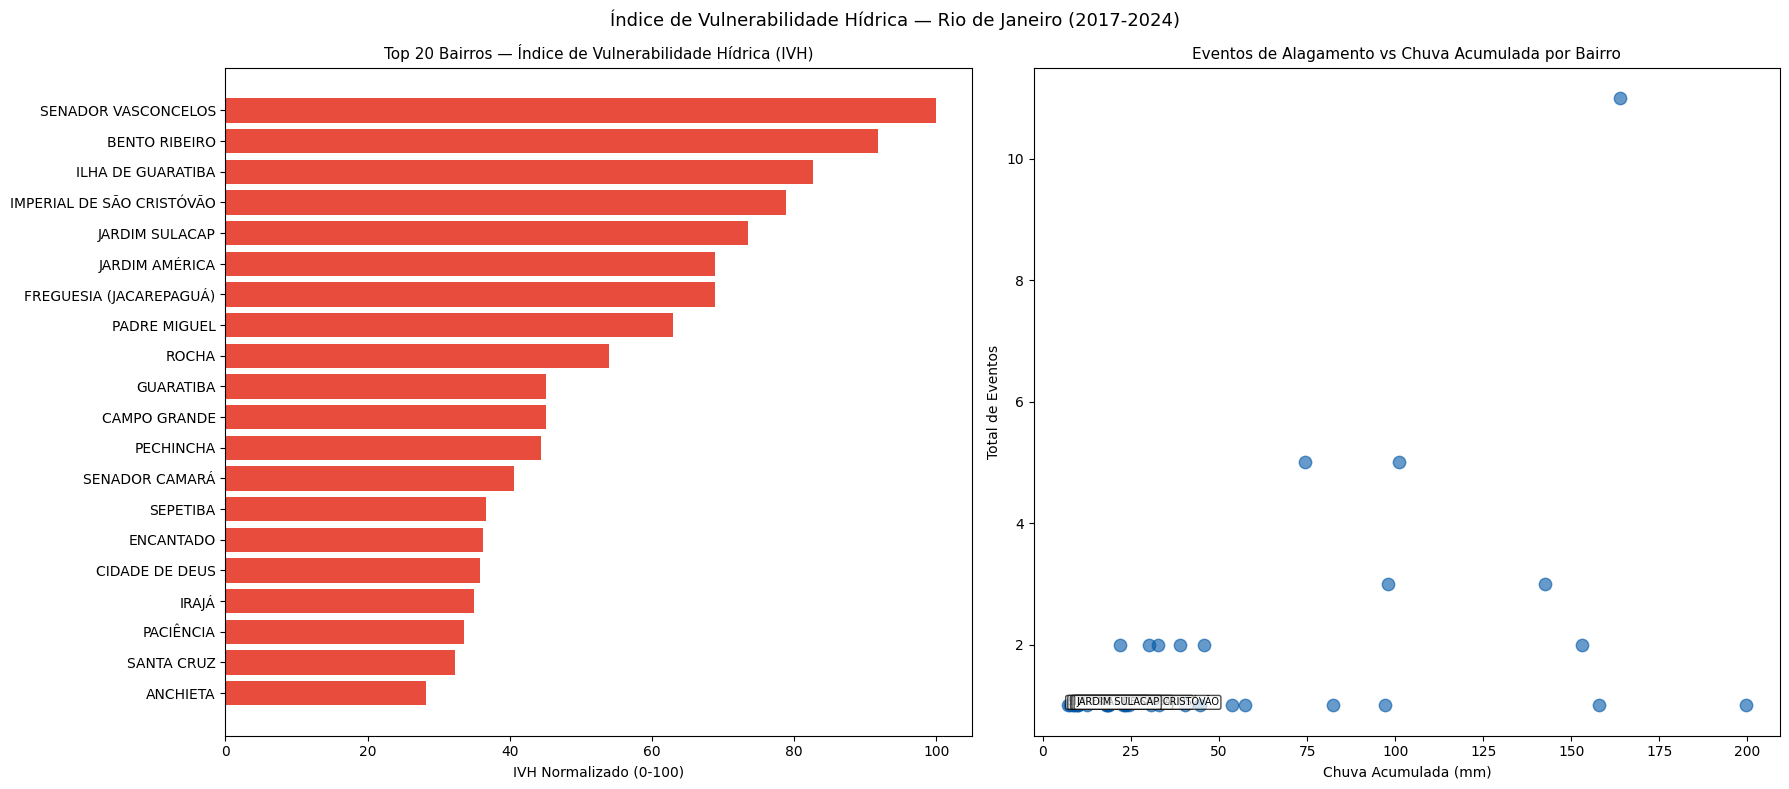

In [7]:
# ── Célula 6: visualização do índice ──

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Gráfico 1: Top 20 bairros por IVH normalizado
top20 = vulnerabilidade.head(20)
axes[0].barh(top20["bairro"][::-1], top20["ivh_normalizado"][::-1], color="#E74C3C")
axes[0].set_title("Top 20 Bairros — Índice de Vulnerabilidade Hídrica (IVH)", fontsize=11)
axes[0].set_xlabel("IVH Normalizado (0-100)")

# Gráfico 2: eventos vs chuva acumulada por bairro
axes[1].scatter(
    vulnerabilidade["total_chuva_mm"],
    vulnerabilidade["total_eventos"],
    alpha=0.6, color="#0057A8", s=80
)

# Destacar top 5
top5 = vulnerabilidade.head(5)
for _, row in top5.iterrows():
    axes[1].annotate(
        row["bairro"],
        xy=(row["total_chuva_mm"], row["total_eventos"]),
        fontsize=7,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7)
    )

axes[1].set_title("Eventos de Alagamento vs Chuva Acumulada por Bairro", fontsize=11)
axes[1].set_xlabel("Chuva Acumulada (mm)")
axes[1].set_ylabel("Total de Eventos")

plt.suptitle("Índice de Vulnerabilidade Hídrica — Rio de Janeiro (2017-2024)", fontsize=13)
plt.tight_layout()
plt.savefig("../figuras/indice_vulnerabilidade_hidrica.png", dpi=150)
plt.show()

In [14]:
# ── Célula 7: salvar ──
vulnerabilidade.to_parquet(
    "../data/processed/indice_vulnerabilidade_hidrica.parquet", index=False
)
vulnerabilidade.to_csv(
    "../data/processed/indice_vulnerabilidade_hidrica.csv", index=False
)

print("Índice salvo!")
print(f"  Bairros no índice: {len(vulnerabilidade)}")
print(f"  Colunas: {vulnerabilidade.columns.tolist()}")
print(f"\nResumo:")
print(vulnerabilidade[["bairro", "total_eventos", "ivh_normalizado"]].describe().round(1))

Índice salvo!
  Bairros no índice: 37
  Colunas: ['bairro', 'total_eventos', 'total_chuva_mm', 'media_chuva_mm', 'mediana_indice', 'dias_com_evento', 'anos_cobertos', 'ivh', 'ivh_normalizado']

Resumo:
       total_eventos  ivh_normalizado
count           37.0             37.0
mean             1.8             36.0
std              1.9             26.8
min              1.0              0.0
25%              1.0             14.4
50%              1.0             32.3
75%              2.0             45.1
max             11.0            100.0
